## What's Liouville space?
Before we answer that question, let's review the more familiar Hilbert space.
### Hilbert space
Suppose we have a Hamiltonian, $\hat{H}$, in Hilbert space. For a simulation, that means we have an $m\times m$ matrix in our computer memory representing the Hamiltonian. In this case, $m=\prod_{i=1}^N{(2*S_i+1)}$, where $S_i$ is the spin of the $i^{th}$ nucleus or electron. Let's have a look at this in SLEEPY.


In [3]:
import sys
sys.path.append('/Users/albertsmith/Documents/GitHub/SLEEPY/')

In [5]:
import SLEEPY as sl
import numpy as np
import matplotlib.pyplot as plt

Below, we look at a Hamiltonian. The two spin-1/2 system gives a 4x4 matrix ($m=(2*1/2+1)*(2*1/2+1)=4$)

In [19]:
ex=sl.ExpSys(600,Nucs=['1H','1H'])
ex.set_inter('CS',i=0,ppm=1)
ex.set_inter('CS',i=0,ppm=5)
ex.set_inter('J',i0=0,i1=1,J=200)
H=ex.Hamiltonian()

In [20]:
H.H()

array([[ 1550.+0.j,     0.+0.j,     0.+0.j,     0.+0.j],
       [    0.+0.j,  1450.+0.j,   100.+0.j,     0.+0.j],
       [    0.+0.j,   100.+0.j, -1550.+0.j,     0.+0.j],
       [    0.+0.j,     0.+0.j,     0.+0.j, -1450.+0.j]])

We can also visualize the Hamiltonian:

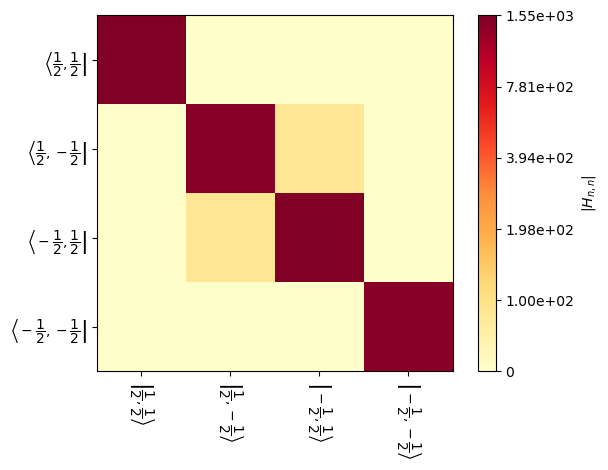

In [27]:
_=H.plot()

In Hilbert space, the current state of the spin system is described by a square density matrix (also $mxm$), often denoted with $\hat{\rho}(t)$. Diagonal elements of the density matrix specify how much population is in each of the eigenstates of the Zeeman Hamiltonian, and off-diagonal elements specify populations of coherences between those  states. $\hat{\rho}(t)$ will evolve in time depending on the Hamiltonian, according to:
$$
\begin{equation}
\hat{\rho}(t+\Delta t)=\exp{(-i\hat{H}\Delta t)}\hat{\rho}(t)\exp{(i\hat{H}\Delta t)}
\end{equation}
$$
Note, here we assume a time-independent Hamiltonian. In SLEEPY simulations, we handle time-dependence by breaking simulations into small, time-independent steps, a common approach in NMR simulation. Note that to propagate the density matrix, we have sandwiched it between two matrix exponentials. 

*A few notes of caution:* These operations require matrix multiplication, not elementwise multiplication, and the $\exp$ indicates a matrix exponential, not an elementwise exponential. Our notation here assumes the Hamiltonian in radians/s, not Hz, which would require multiplying by $2\pi$.

Often, we define a propagator, such that

$$
\begin{eqnarray}
\hat{U}(\Delta t)&=&\exp{(-i\hat{H} \Delta t)} \\
\hat{\rho}(t+\Delta t)&=&\hat{U}(\Delta t)\hat{\rho}(t)\hat{U}^\dagger(\Delta t)
\end{eqnarray}
$$

So, here arises the problem with Hilbert space: It is not straightforward to create a system that exchanges between two or more Hamiltonians in a stochastic manner when we have the square density matrix and sandwiched multiplication. This brings us to Liouville space.

## Liouville space
Liouville space may be constructed from Hilbert space, by first stretching the $m\times m$ density matrix into a length $m^2$ vector, and second, calculating the Liouvillian from the Hamiltonian, according to
$$
\begin{equation}
\hat{\hat{L}}=\hat{H}\otimes\hat{\mathbf{1}}-\hat{\mathbf{1}}\otimes\hat{H}^T
\end{equation}
$$
In the above equation, $\otimes$ is the [Kronecker product](https://en.wikipedia.org/wiki/Kronecker_product), $\hat{\mathbf{1}}$ is an identity matrix with the same dimensions as the Hamiltonian, and $\hat{H}^T$ is the transpose (not the complex transpose!) of the Hamiltonian. The result is an $m^2\times m^2$ matrix. We plot this in SLEEPY below.

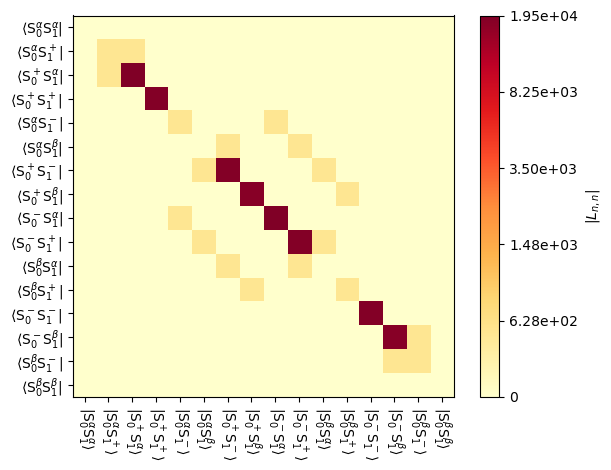

In [26]:
L=H.Liouvillian()
_=L.plot()